# (1) Title Page

**Title:** Infering and Predicting Fire Spread Rate
**Group Name:** we
**Group #:** 32 <br>

**Group Members:** Daniel Wick, Maggie Wang, Emmy Yu Ting Wong, Zirun Xu <br>
**Course:** Stats 301 102
**Date:** 2026-04-16

In [1]:
suppressPackageStartupMessages({
  devtools::install_github("diverse-data-hub/diversedata")
  library(diversedata)
  library(dplyr)
  library(ggplot2)
  library(broom)
  library(tidyverse)
  library(modelr)
  library(yardstick)
  library(MASS)
  library(car)
  library(tidyverse)
  library(rsample)   
  library(leaps)     
  library(glmnet)
  library(knitr) #for drop_na() table in EDA
  select <- dplyr::select
  my_metrics <- yardstick::metric_set(yardstick::rmse, yardstick::rsq)
})

Warning message:
"`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead."

Please download and install Rtools 4.5 from https://cran.r-project.org/bin/windows/Rtools/.

Skipping install of 'diversedata' from a github remote, the SHA1 (4d9ebacf) has not changed since last install.
  Use `force = TRUE` to force installation



# (2) Introduction

Start with relevant background information on the topic to prepare those unfamiliar for the rest of your proposal. Motivate the question you are about to add.

Formulate one or two questions for investigation indicating if the primary goal is inference or prediction. Make sure that the question(s) can be answer with the data available. For example, you won't be able to quantify the "effect of X on Y" or "the influence of X on Y" or "how X affects Y" using the methods learned in class and observational data.

If available, align your question/objectives with the existing literature on the topic. You can add a reference to a scientific publication if available and listed in the References section (not mandatory). 


proposed question:
> Given that a fire is actively spreading, to what extent do meteorological factors predict the spread rate of a wildfire?
This question focuses on both prediction and inference, as we aim to build a predictive model while also inferring which specific weather condition drives the fastest spread. The response variable will be fire_spread_rate, and the primary covariates I anticipate being most important are temperature, relative_humidity, and wind_speed. Other variables like fuel_type and assessment_hectares can be used to control for difference types of vegetation initial size of the fire. Different fuel types will burn at different rates, and a larger fire will likely burn faster because dries out surrounding fuel faster, generates more heat, and generates its own winds.

# (3) Methods and Results

## (a) Data

In [2]:
#read data into R
data("wildfire")

  Burak K, Khoda E, Piran A, Ramirez F, Subrahmanian S (2026).
  _diversedata: A Curated Collection of Datasets on Diverse Topics_. R
  package version 1.0.1, commit
  4d9ebacf2d2afa0a3aa3ab894492f3482117f1f3,
  <https://github.com/diverse-data-hub/diversedata>.

Data was collected by the Government of Alberta by geospatial and satellite tracking. They used satellite imagery or aerial surveying to map the sizes and boundaries of the fires. Additionally observational data was collected by assessment crews.

In [3]:

variable_info <- tibble(
  Variable_Name = names(wildfire),
  Data_Type = sapply(wildfire, function(x) class(x)[1])
)


variable_info

Variable_Name,Data_Type
<chr>,<chr>
year,numeric
fire_number,character
current_size,numeric
size_class,character
latitude,numeric
longitude,numeric
fire_origin,character
general_cause,character
responsible_group,character



## Variables

#### Response Variable:
**fire_spread_rate:** Rate at which the wildfire spread in metres/minute at the time of initial assessment <br>
#### Input Variables: 


To include
**temperature:** Temperature at the wildfire location in °C at the time of initial assessment<br>
**relative_humidity:** Relative humidity at the wildfire location at the time of initial assessment<br>
**wind_speed:** Wind speed at the wildfire location in km/h at the time of initial assessment<br>
**assessment_hectares:** Size of the wildfire in hectares at the time of assessment <br>
**fuel_type:** Dominant fuel type (vegetation cover) in which the wildfire is burning at the wildfire location at the time of initial assessment. 
- Coniferous (C) e.g. "C2" is Boreal Spruce
- Deciduous (D)
- Mixedwood (M) e.g. "M2" is Boreal Mixedwood - Green. Its a mix of spruce and aspen when the leaves are grean.
- Open (O) e.g. O1a is matted grass. Dead, flat grass in the early spring. O1b is standing grass. Upright, dry grass. <br>
**weather_conditions_over_fire:** Weather conditions over the wildfire at the time of initial assessment <br>
**fire_type:** Predominant wildfire behavior classification at the time of initial assessment (e.g., "Surface", "Ground", "Crown") <br>
**fire_position_on_slope:** Position of the wildfire relative to the slope it is travelling on at the time of initial assessment (e.g., "Bottom", "Middle 1/3", "Unknown") <br>


To Exclude

1. Identifiers & Spatial Data (Causes Overfitting)
These are just numbers on a map or in a database. They have no physical impact on how fast a fire burns.
**fire_number:** Identifier for the wildfire <br>
**latitude:** Latitude coordinate of the wildfire origin <br>
**longitude:** Longitude coordinate of the wildfire origin <br>
**year:** Year in which the wildfire was first detected <br>
**wind_direction:** Wind direction at the wildfire location at the time of initial assessment <br>
- wind direction is relative and doesnt affect the fire.


2. Human/Administrative Factors (Irrelevant to Spread)
A fire doesn't care how it started; once it's burning, it only cares about the wind and the wood. Whether a fire was started by a camper or lightning does not change the physics of its spread.
**fire_origin:** Who owns or administers the land the wildfire ignited on <br>
**responsible_group:** Recreational group responsible for causing the wildfire <br>
**activity_class:** Activity that was going on when the wildfire started <br>
**detection_agent_type:** Type of detection agent that discovered the wildfire (e.g., lookout ("LKT"), aircraft ("AIR")) <br>
**detection_agent:** Specific type of detection agent that discovered the wildfire <br>
**general_cause:** Classification of the wildfire cause <br>
**true_cause:** Specific reason why the wildfire started (e.g., "Arson Known", "Hot Exhaust", "Line Impact", "Unattended Fire", etc.) <br>
**initial_action_by:** Group that initiated suppression efforts <br>
**fire_start_date:** Datetime the wildfire started <br>
**ia_access:** Method of access that the initial action group used <br>
**ia_arrival_at_fire_date:** Datetime when the initial action group arrived at the wildfire <br>
**fire_fighting_start_date:** Datetime when the initial action group began firefighting activities <br>


3. Data Leakage (Events from the Future After Initial Assessment)
Since fire_spread_rate is collected at the time of the initial assessment, any variables gathered after the initial assessment will not affect fire_spread_rate.



**fire_fighting_start_size:** Wildfire size at the time firefighting began in hectares <br>
**bucketing_on_fire:** Whether aerial bucketing was used on the wildfire <br> 
Helicopter bucketing is a response to high spread rates, not a physical driver of them. Including it introduces endogeneity and acts as a proxy for fire severity rather than a true meteorological or environmental predictor.<br>
**first_bh_date:** Datetime when wildfire was first declared being held <br>
**first_bh_size:** Wildfire size when wildfire was first declared being held in hectares <br>
**first_uc_date:** Datetime when wildfire was first declared under control <br>
**first_uc_size:** Wildfire size when first declared under control in hectares <br>
**first_ex_size_perimeter:** Wildfire size when first declared extinguished in hectares <br>
**size_class:** Size classification based on final area burned <br>
**current_size:** Final estimated area burned by the wildfire <br>




## (b) Exploratory Data Analysis (EDA)

In [25]:
clean_wildfire <- wildfire |>
  select(
    # The Target Variable (Must keep for the y_vector)
    fire_spread_rate,
    
    # Meteorological Drivers
    temperature, 
    relative_humidity, 
    wind_speed, 
        weather_conditions_over_fire,
    
    # Environmental & Fuel Drivers
    fuel_type, 
    fire_position_on_slope,
    
    # Initial Fire Characteristics
    assessment_hectares, 
    fire_type
  ) |>
  mutate(across(where(is.character), as.factor))|>
  # Count how many times each fuel type appears, keep only common ones
  group_by(fuel_type) |>
  filter(n() >= 10) |> # filters out low sample size fuel_types
  ungroup() 
  head(clean_wildfire, 3)

dim(clean_wildfire)

fire_spread_rate,temperature,relative_humidity,wind_speed,weather_conditions_over_fire,fuel_type,fire_position_on_slope,assessment_hectares,fire_type
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>
0,18,10,2,Clear,O1a,Flat,0.01,Surface
0,12,22,10,Clear,O1a,Lower 1/3,0.20,Surface
0,12,22,10,Clear,O1a,Bottom,0.50,Surface


[1] 26545     9

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 2891 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 2880 rows containing missing values or values outside the scale range
(`geom_point()`)."


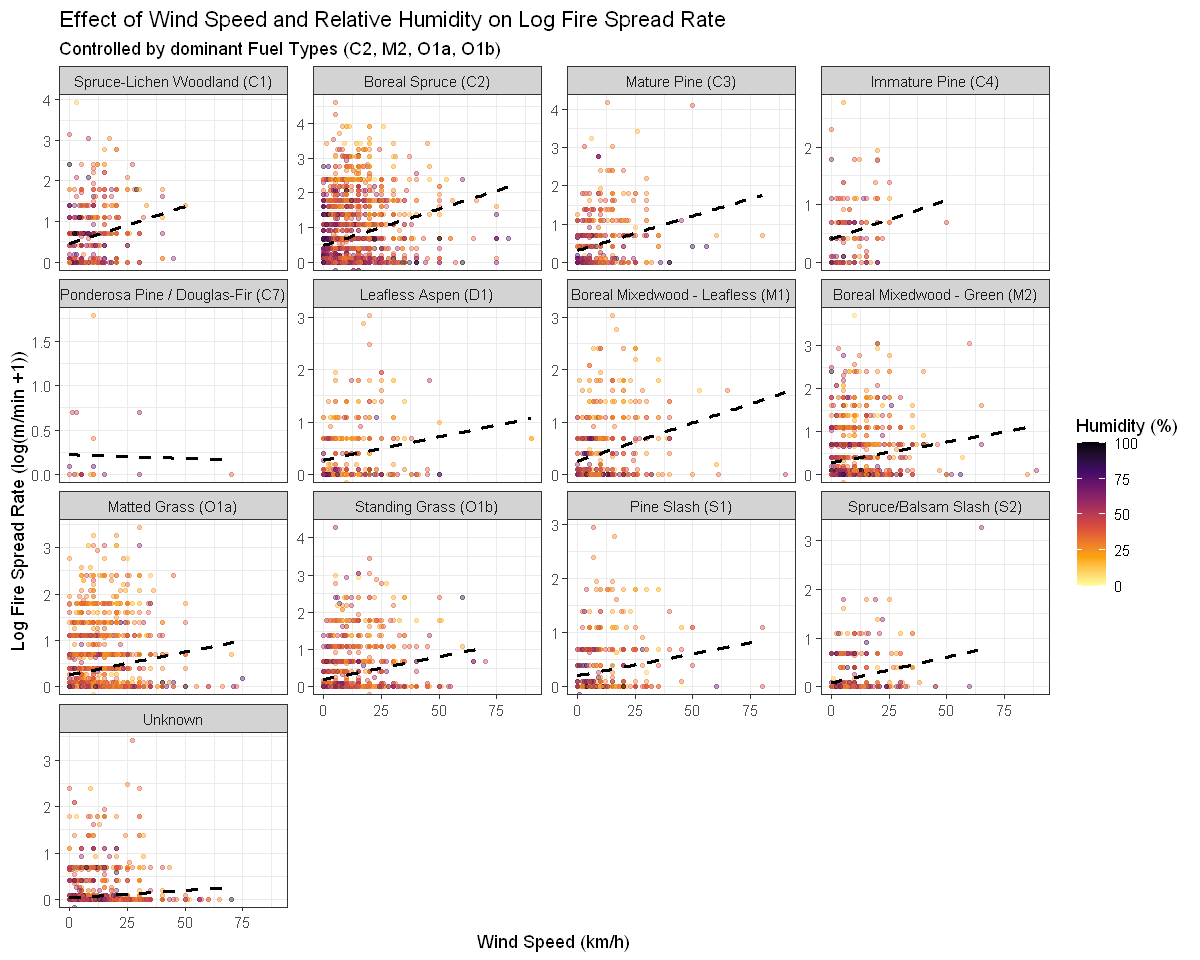

In [26]:
fuel_type_labels <- c(
  "C1"      = "Spruce-Lichen Woodland (C1)",
  "C2"      = "Boreal Spruce (C2)",
  "C3"      = "Mature Pine (C3)",
  "C4"      = "Immature Pine (C4)",
  "C6"      = "Conifer Plantation (C6)",
  "C7"      = "Ponderosa Pine / Douglas-Fir (C7)",
  "D1"      = "Leafless Aspen (D1)",
  "M1"      = "Boreal Mixedwood - Leafless (M1)",
  "M2"      = "Boreal Mixedwood - Green (M2)",
  "M3"      = "Dead Balsam Fir - Leafless (M3)",
  "M4"      = "Dead Balsam Fir - Green (M4)",
  "O1a"     = "Matted Grass (O1a)",
  "O1b"     = "Standing Grass (O1b)",
  "S1"      = "Pine Slash (S1)",
  "S2"      = "Spruce/Balsam Slash (S2)",
  "Unknown" = "Unknown"
)


options(repr.plot.width = 10, repr.plot.height = 8)


ggplot(clean_wildfire, aes(x = wind_speed, y = log(fire_spread_rate + 1))) +
  geom_point(aes(color = relative_humidity), alpha = 0.4, size = 1) +
  geom_smooth(method = "lm", color = "black", linetype = "dashed", se = FALSE) +
  facet_wrap(~ fuel_type, scales = "free_y", labeller = as_labeller(fuel_type_labels)) +
  scale_color_viridis_c(option = "inferno", direction = -1) +
  labs(
    title = "Effect of Wind Speed and Relative Humidity on Log Fire Spread Rate",
    subtitle = "Controlled by dominant Fuel Types (C2, M2, O1a, O1b)",
    x = "Wind Speed (km/h)",
    y = "Log Fire Spread Rate (log(m/min +1))",
    color = "Humidity (%)"
  ) +
  theme_bw() +
  theme(strip.background = element_rect(fill = "lightgray"))


This visualization is highly relevant because it directly addresses both the predictive and inferential aspects of my research question while demonstrating the necessity of control variables. 


By mapping wind_speed to the x-axis and relative_humidity to the color gradient, I can explore how multiple meteorological predictors simultaneously influence the fire_spread_rate.


Furthermore, faceting the plot by fuel_type visually isolates the environment, allowing me to observe the unique linear trend (black dashed line) for each specific vegetation type. 


This confirms that fuel_type strongly dictates baseline fire behavior and must be held constant in a multiple regression model to accurately infer the independent effects of the weather. 


In [27]:
### Transform Variables


# clean_wildfire

transformed_clean_wildfire <- clean_wildfire |>
  # 1. REMOVE negative placeholders before logging
  filter(fire_spread_rate >= 0) |> 
  
  # 2. Now it is safe to log
  mutate(fire_spread_rate = log(fire_spread_rate + 1)) |>  
  mutate(wind_speed_sq = wind_speed^2) |>
    # 3. Double-check for any bizarre Inf values just to be bulletproof
  filter(!is.infinite(fire_spread_rate))
  
  head(transformed_clean_wildfire, 3)

fire_spread_rate,temperature,relative_humidity,wind_speed,weather_conditions_over_fire,fuel_type,fire_position_on_slope,assessment_hectares,fire_type,wind_speed_sq
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>
0,18,10,2,Clear,O1a,Flat,0.01,Surface,4
0,12,22,10,Clear,O1a,Lower 1/3,0.20,Surface,100
0,12,22,10,Clear,O1a,Bottom,0.50,Surface,100


In [28]:
#percent NAs per variable
na_percentages <- colMeans(is.na(wildfire)) * 100
missing_data_table <- tibble(
  Variable = names(na_percentages),
  Percentage_NA = na_percentages
) |>
  arrange(desc(Percentage_NA)) |>
  head(5)

  # See how many rows you have before and after droping NA's
# nrow(wildfire)
# nrow(drop_na(wildfire))
# colSums(is.na(wildfire)) |> sort(decreasing = TRUE)
# nrow(clean_wildfire)
# nrow(drop_na(clean_wildfire))
# colSums(is.na(clean_wildfire)) |> sort(decreasing = TRUE)
# Creating the summary data frame
cleaning_summary <- tribble(
  ~Metric, ~wildfire, ~clean_wildfire,
  "Total Observations", "26,551", "23,549",
  "Rows lost to drop_na()", "10,600", "3,002",
  "Data Retention (%)", "60.1%", "88.7%",
  "Top Offender 1", "ia_arrival_at_fire_date (7,703)", "REMOVED",
  "Top Offender 2", "fire_fighting_start_date (7,572)", "REMOVED"
)

head(missing_data_table)

# Outputting as a clean table
kable(cleaning_summary, caption = "Summary of Data Cleaning and Row Retention")
# percent of each category
wildfire |>
  count(fuel_type) |>
  mutate(percentage = n / sum(n) * 100) |>
  arrange(desc(percentage))
  

wildfire |>
  summarize(
    total_fires = n(),
    zero_spread_count = sum(fire_spread_rate == 0.0),
    percentage_zero = (zero_spread_count / total_fires) * 100
  )

Variable,Percentage_NA
<chr>,<dbl>
ia_arrival_at_fire_date,29.01209
fire_fighting_start_date,28.51870
wind_speed,10.84705
relative_humidity,10.83952
temperature,10.81692




Table: Summary of Data Cleaning and Row Retention

|Metric                 |wildfire                         |clean_wildfire |
|:----------------------|:--------------------------------|:--------------|
|Total Observations     |26,551                           |23,549         |
|Rows lost to drop_na() |10,600                           |3,002          |
|Data Retention (%)     |60.1%                            |88.7%          |
|Top Offender 1         |ia_arrival_at_fire_date (7,703)  |REMOVED        |
|Top Offender 2         |fire_fighting_start_date (7,572) |REMOVED        |

fuel_type,n,percentage
<chr>,<int>,<dbl>
Unknown,7559,28.469737486
C2,6785,25.554593047
O1a,4191,15.784716207
M2,2367,8.914918459
O1b,2005,7.551504651
C3,715,2.692930586
M1,705,2.655267222
C1,586,2.207073180
S1,510,1.920831607


total_fires,zero_spread_count,percentage_zero
<int>,<int>,<dbl>
26551,12487,47.03024


The 2 variables that have the highest percentage of NAs at 29% are irrelevant because they do not affect the initial fire spread rate. The other variabales are <11% NAs. These 2 variables `ia_arrival_at_fire_date` `fire_fighting_start_date` were removed to preserve the rest of the dataset not only because of their high % of NAs but also because they are irrelevant to fire_spread_rate.  <br>

The "Unknown" and "C2" fuel types take up the majority of the observations. The "Unknown" could be any combination of the other fuel types.


Much of the fire_spread_rate is exactly 0.0 metres/minute at the time of assessment.

# (c) Methods: Plan

### Method

The proposed method is a Multiple Linear Regression (MLR) model, paired with LASSO for variable selection. This method is appropriate because the response variable (fire_spread_rate) is continuous and numerical, and we aim to quantify its linear relationship with multiple continuous meteorological predictors. LASSO was specifically chosen as a preliminary step to handle potential multicollinearity among the weather variables and perform objective feature selection.


Create 3 partitions of the data. One for model selection, fitting, and testing the model ensuring to stratify the data to ensure the response variable isn't biased.
I will use LASSO for model selection, allowing it to select the variables and interactions while minimizing lambda using the model selection partition. Then I will use LASSO to fit the selected model using the fitting partition. Finally I will test the model with the test partition.



#### Reasoning
Keeping the 3 partitions separate prevents bias in the model from double dipping.


### Assumptions and Limitations

Linearity:
MLR assumes a linear relationship and constant variance (homoscedasticity). A major limitation here is that wildfire spread is likely exponential or non-linear under extreme weather. Furthermore, the variance of spread rates likely increases as fires get larger, which violates the equal variance assumption.

Independence:
Observations are of independent fires

Multicollinearity:
Meteorological factors like temperature and humidity are naturally correlated. Using LASSO helps mitigate this limitation by shrinking redundant covariates

In [29]:
# 1. Final Safety Check (Ensure X and Y dimensions will match) - model.matrix automatically ommits NAs
clean_wildfire_model_data <- transformed_clean_wildfire |> drop_na()

# 2. Train / Test Split
set.seed(123)
initial_split_obj <- initial_split(clean_wildfire_model_data, prop = 0.80, strata = fire_spread_rate)
training_data <- training(initial_split_obj)
testing_data <- testing(initial_split_obj)

# 3. Build the Training Matrix
x_train <- model.matrix(
  fire_spread_rate ~ (.)^2,
  data = training_data
)[, -1]

y_train <- training_data$fire_spread_rate

# 4. Train the LASSO Model
cv_lasso <- cv.glmnet(x_train, y_train, alpha = 1)

# 5. Build the Testing Matrix & Predict
x_test <- model.matrix(
  fire_spread_rate ~ (.)^2,
  data = testing_data
)[, -1]

lasso_predictions <- predict(cv_lasso, newx = x_test, s = "lambda.min")

# 6. Evaluate Performance (Log-Scale)
testing_data_with_preds <- testing_data |>
  mutate(predicted_rate = as.numeric(lasso_predictions))

# Calculate metrics on the log-scale
metrics <- metric_set(rmse, rsq)

testing_data_with_preds |>
  metrics(truth = fire_spread_rate, estimate = predicted_rate)

# 7. View the Surviving Coefficients for inference model
lasso_coefs <- coef(cv_lasso, s = "lambda.min")
active_coefs <- lasso_coefs[lasso_coefs[, 1] != 0, ]
sorted_coefs <- sort(abs(round(active_coefs, 4)), decreasing = TRUE)
print(sorted_coefs)


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,0.5098531
rsq,standard,0.2733880


                                   (Intercept) 
                                        0.4882 
                               fire_typeGround 
                                        0.2506 
                              fuel_typeUnknown 
                                        0.1385 
                              fire_typeSurface 
                                        0.1219 
             fuel_typeUnknown:fire_typeSurface 
                                        0.0103 
                       temperature:fuel_typeC2 
                                        0.0086 
                        wind_speed:fuel_typeC2 
                                        0.0045 
                  temperature:fuel_typeUnknown 
                                        0.0034 
                                   temperature 
                                        0.0024 
            relative_humidity:fire_typeSurface 
                                        0.0024 
             relative_humidity:fire_type

In [30]:
selected_formula <- fire_spread_rate ~ fire_type +
fuel_type +
temperature:fuel_type +
temperature +
wind_speed:fuel_type +
wind_speed +
relative_humidity:fire_type +
relative_humidity +
fuel_type:fire_position_on_slope +
fire_position_on_slope +
temperature:fire_position_on_slope +
temperature:wind_speed +
assessment_hectares  +
temperature:assessment_hectares +
wind_speed:assessment_hectares 



# ---------------------------------------------------------
# Post-selection. Fitting the linear model to testing_data for inference
# ---------------------------------------------------------

inference_model <- lm(selected_formula, data = testing_data)

# look at the summary for valid inference
summary(inference_model)


Call:
lm(formula = selected_formula, data = testing_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7649 -0.3057 -0.0828  0.1895  3.9273 

Coefficients: (15 not defined because of singularities)
                                                    Estimate Std. Error t value
(Intercept)                                        9.057e-01  3.168e-01   2.859
fire_typeGround                                   -1.309e+00  9.711e-02 -13.476
fire_typeSurface                                  -1.112e+00  9.179e-02 -12.113
fire_typeUnknown                                  -3.541e-01  4.831e-01  -0.733
fuel_typeC2                                        5.277e-01  3.007e-01   1.755
fuel_typeC3                                        3.279e-01  3.577e-01   0.917
fuel_typeC4                                       -6.862e-02  6.046e-01  -0.113
fuel_typeC7                                       -3.323e+00  5.320e+00  -0.625
fuel_typeD1                                        5.261e-01  3.942e-0

`geom_smooth()` using formula = 'y ~ x'


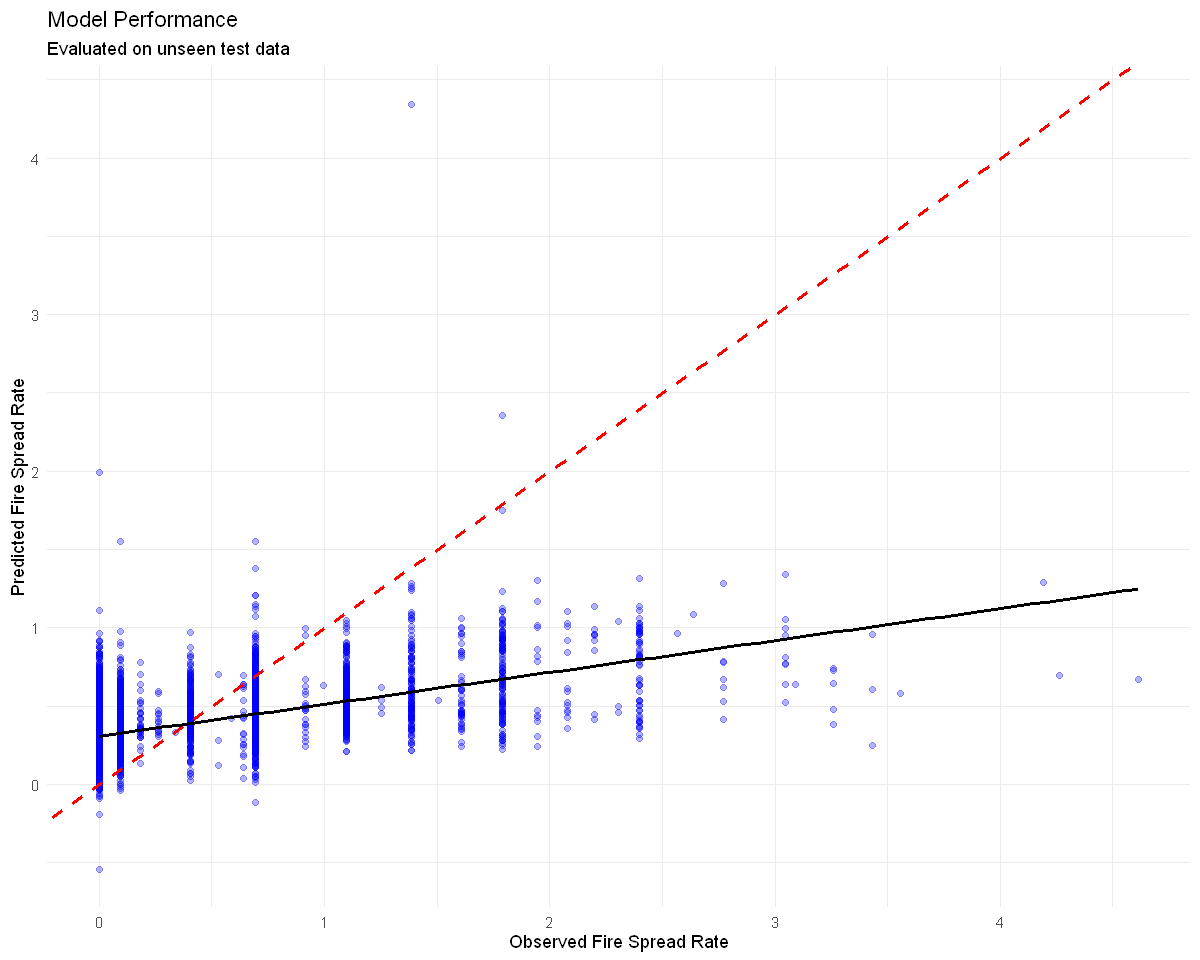

In [31]:
ggplot(testing_data_with_preds, aes(x = fire_spread_rate, y = predicted_rate)) +
  geom_point(alpha = 0.3, color = "blue") +
  geom_abline(intercept = 0, slope = 1,          # Adds the "Perfect Prediction" reference line
              color = "red", linetype = "dashed", size = 1) +
  geom_smooth(method = "lm", color = "black", se = FALSE) + # Adds the actual trend of predictions
  labs(
    title = "Model Performance",
    subtitle = "Evaluated on unseen test data",
    x = "Observed Fire Spread Rate",
    y = "Predicted Fire Spread Rate"
  ) +
  theme_minimal()

Evaluating the LASSO-selected model on unseen test data yielded an $R^2$ of 0.275 and an RMSE of 2.11, confirming that a combination of meteorological factors and fire type provides a statistically significant predictive baseline. Specifically, the model successfully inferred that relative humidity dampens fire spread, while ground and surface fires move significantly slower than other types. However, an $R^2$ of 27.5% means the model still leaves a vast majority of the variance unexplained. This large discrepancy indicates that critical explanatory variables such as topography or non-linear weather interactions are currently missing from the model.

Perhaps 47% of the fire_spread_rate in the dataset being 0.0 m/min is messing up the model's prediction.

In [32]:
# Define a null model and a full model
wildfire_null <- lm(fire_spread_rate ~ 1, data = training_data)
wildfire_all <- lm(fire_spread_rate ~., data = training_data)

In [33]:
# Add a column with predictions to the validation set (fit_data)
test_predictions <- training_data %>%
    add_predictions(inference_model, var = "pred_LASSO") %>%
    add_predictions(wildfire_null, var = "pred_null") %>%
    add_predictions(wildfire_all, var = "pred_all")

# Calculate RMSE and R-squared to assess accur acy
metrics <- metric_set(rmse, rsq, mae)

# Add GOF metrics for null and interaction model
metrics_summary <- cbind(
    metrics(test_predictions, truth = fire_spread_rate, estimate = pred_LASSO),
    all = metrics(test_predictions, truth = fire_spread_rate, estimate = pred_all)$.estimate,
    null = metrics(test_predictions, truth = fire_spread_rate, estimate = pred_null)$.estimate
)

metrics_summary <- rename(metrics_summary, lasso = .estimate)

metrics_summary

Warning message in predict.lm(model, data):
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message:
"A correlation computation is required, but `estimate` is constant and has 0
standard deviation, resulting in a divide by 0 error. `NA` will be returned."


.metric,.estimator,lasso,all,null
<chr>,<chr>,<dbl>,<dbl>,<dbl>
rmse,standard,0.5211016,0.4867723,0.5854620
rsq,standard,0.2441713,0.3087195,NA
mae,standard,0.3551704,0.3574004,0.4555807


The table `metrics_summary` contains goodness-of-fit metrics for the MLR model fitted through LASSO variable selection, the null model (intercept only) and the full model with all predictors. The LASSO model performs slightly better than the interaction and null models, with the lowest RMSE and MAE and the highest $R^2$, although overall performance remains weak. The low $R^2$ value indicates that very little of the variability in the fire spread rate is explained by the environmental variables. The RMSE and MAE of the LASSO model are not much lower than the null model, which suggests that the model may be missing stronger predictors.

# (4) Discussion

### Summary
The model fit through LASSO variable selection is performing slightly better than the full model and the null model, but still has low $R^2$ (0.275 on the test set). This indicates that only about 27.5% of the variability is explained, which is relatively low for predictive purposes, though not unexpected given the complex interactions between environmental variables. The RMSE and MAE values are not much lower than the null model, indicating that the LASSO model has low predictive power. LASSO selects variables by penalizing and removing the least important ones, so the low predictive power of this model suggests that even the best subset of predictors may not be strongly associated with the response variable. The analysis may be missing more powerful predictors such as the weather conditions over the fire (rainy vs. clear day) or the firefighting techniques used on it.

### Assumptions and limitations

- Linearity: MLR assumes a linear relationship and constant variance (homoscedasticity). A major limitation here is that wildfire spread is likely exponential or non-linear under extreme weather. Furthermore, the variance of spread rates likely increases as fires get larger, which violates the equal variance assumption.
- Independence: We assume that observations are of independent fires
- Multicollinearity: Meteorological factors like temperature and humidity are naturally correlated. Using LASSO helps mitigate this limitation by shrinking redundant covariates
- Confounding variables: Other environmental conditions such as the weather conditions preceding the fire (affecting how dry the fuel is) or how dense the brush is in the area surrounding the fire could impact the fire spread rate.

# (5) References


add reference